# 04 — Next steps: filling the gaps

Each section here matches one gap from that document and is meant to be run **after** the three existing notebooks have produced `data/cleaned/dpe_clean_model_ready.parquet`.

Sections:
1. Setup, paths, reusable preprocessor
2. Wider model menu (`make_model_zoo`) 
3. Hyper-parameter tuning with `RandomizedSearchCV` 
4. Richer evaluation (ROC, PR, calibration, residuals)
5. Permutation importance / SHAP 
6. Leakage ablation on boosted models
7. Fair regression-vs-classification comparison
8. Class-imbalance experiments (SMOTE + threshold tuning) 
9. Pick a champion per task, persist it 
10. Presentation-ready figures 
11. Export `requirements.txt` 


## 1. Setup, paths, reusable preprocessor

In [3]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

DATA_PATH = Path("../data/cleaned/dpe_clean_model_ready.parquet")
REPORTS_DIR = Path("../reports/modeling")
MODELS_DIR = Path("../models")
FIG_DIR = Path("../figures/presentation")
for d in (REPORTS_DIR, MODELS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

TARGET_ERA = "construction_era"
TARGET_BINARY = "pre_post_1975"
TARGET_YEAR = "annee_construction"

# Ordered era labels and the int <-> label maps (used for ordinal regression in Protocol B
# and the within-1-era accuracy metric).
ERA_LABELS = ["pre-1948", "1948-1974", "1975-1988", "1989-2000", "2001-2012", "2013+"]
era_to_idx = {label: i for i, label in enumerate(ERA_LABELS)}
idx_to_era = {i: label for label, i in era_to_idx.items()}

DROP_COLS = [TARGET_ERA, TARGET_BINARY, TARGET_YEAR, "target_source", "split"]

df = pd.read_parquet(DATA_PATH)
print(f"Loaded {DATA_PATH}: {df.shape[0]:,} rows x {df.shape[1]} cols")

ALL_FEATURES = [c for c in df.columns if c not in DROP_COLS]
X = df[ALL_FEATURES].copy()
y_era = df[TARGET_ERA].astype(str)
y_binary = df[TARGET_BINARY].astype(str)
y_year = pd.to_numeric(df[TARGET_YEAR], errors="coerce")

train_mask = df["split"] == "train"
test_mask = df["split"] == "test"
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_era_train, y_era_test = y_era.loc[train_mask], y_era.loc[test_mask]
y_binary_train, y_binary_test = y_binary.loc[train_mask], y_binary.loc[test_mask]

year_train = train_mask & y_year.notna()
year_test = test_mask & y_year.notna()
X_train_yr, X_test_yr = X.loc[year_train], X.loc[year_test]
y_year_train, y_year_test = y_year.loc[year_train], y_year.loc[year_test]

# Ordinal era index (for Protocol B's regression-on-era-index)
y_era_idx = y_era.map(era_to_idx).astype(float)
y_era_idx_train = y_era_idx.loc[train_mask]
y_era_idx_test = y_era_idx.loc[test_mask]

# Sample weights: rows where the era target came from exact `annee_construction`
# are higher-quality labels than rows derived from binned `periode_construction`.
# Give exact-year rows 2x weight in training.
sample_weight_full = np.where(df["target_source"] == "annee_construction", 2.0, 1.0)
sample_weight_train = sample_weight_full[train_mask.values]
sample_weight_train_yr = sample_weight_full[year_train.values]
print(f"Sample weights: mean={sample_weight_train.mean():.3f} "
      f"(1.0=period-derived, 2.0=exact-year)")

numeric_features = X.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [c for c in ALL_FEATURES if c not in numeric_features]

# Department is target-encoded (95 unique values, high cardinality);
# other categoricals get one-hot. This preserves all departments' signal
# without one-hot blow-up.
DEPT_COL = "code_departement_ban"
HIGH_CARDINALITY_CATS = [DEPT_COL] if DEPT_COL in categorical_features else []
onehot_features = [c for c in categorical_features if c not in HIGH_CARDINALITY_CATS]
target_encoded_features = HIGH_CARDINALITY_CATS
print(f"Numeric: {len(numeric_features)} | "
      f"One-hot cats: {len(onehot_features)} | "
      f"Target-encoded cats: {len(target_encoded_features)}")

try:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    _ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_preprocessor(num_cols, oh_cols, te_cols, scale=True):
    """One-hot for low-cardinality cats + target encoding for high-cardinality cats.
    `scale=True` for linear / KNN / SVM / MLP; `False` for tree ensembles."""
    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        num_steps.append(("scaler", StandardScaler()))
    transformers = [("num", Pipeline(num_steps), num_cols)]
    if oh_cols:
        transformers.append(("oh", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("onehot", _ohe),
        ]), oh_cols))
    if te_cols:
        transformers.append(("te", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("target_enc", TargetEncoder(random_state=RANDOM_STATE)),
        ]), te_cols))
    return ColumnTransformer(transformers, remainder="drop")


class CatDtypeMarker(BaseEstimator, TransformerMixin):
    """Convert columns whose names start with `prefix` to pandas categorical dtype.
    Used after a ColumnTransformer (with verbose_feature_names_out=True) so that
    LightGBM can auto-detect categorical features and use native histogram splits."""
    def __init__(self, prefix="cat__"):
        self.prefix = prefix

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            if col.startswith(self.prefix):
                X[col] = X[col].astype("category")
        return X


def make_preprocessor_lgbm(num_cols, cat_cols):
    """Median-impute numerics + ordinal-encode categoricals + mark as pandas
    category dtype for LightGBM native categorical handling."""
    ct = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value",
                                       unknown_value=-1, dtype=np.int64)),
        ]), cat_cols),
    ], remainder="drop")
    ct.set_output(transform="pandas")
    return Pipeline([("ct", ct), ("to_cat", CatDtypeMarker(prefix="cat__"))])


preprocessor = make_preprocessor(numeric_features, onehot_features, target_encoded_features)
preprocessor_tree = make_preprocessor(numeric_features, onehot_features, target_encoded_features, scale=False)
preprocessor_lgbm = make_preprocessor_lgbm(numeric_features, categorical_features)


# Ordinal-aware accuracy: percentage of predictions within N era bins of truth.
# Era labels are ordered 0..5, so distance |pred_idx - true_idx| is meaningful.
def within_n_era_accuracy(y_true, y_pred, n=1, labels=ERA_LABELS):
    label_to_i = {l: i for i, l in enumerate(labels)}
    t = np.array([label_to_i[v] for v in y_true])
    p = np.array([label_to_i[v] for v in y_pred])
    return float((np.abs(t - p) <= n).mean())


Loaded ../data/cleaned/dpe_clean_model_ready.parquet: 49,883 rows x 48 cols
Sample weights: mean=1.583 (1.0=period-derived, 2.0=exact-year)
Numeric: 34 | One-hot cats: 8 | Target-encoded cats: 1


## 2. Wider model menu 

`make_model_zoo('classification')` and `make_model_zoo('regression')` return a `dict[str, Pipeline]` covering: dummy, logistic / ridge, KNN, decision tree, bagging, random forest, hist gradient boosting, SVM, MLP, polynomial ridge (regression), and XGBoost / LightGBM when available.


In [4]:
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    BaggingClassifier, BaggingRegressor,
    RandomForestClassifier, RandomForestRegressor,
    HistGradientBoostingClassifier, HistGradientBoostingRegressor,
)
from sklearn.svm import LinearSVC, LinearSVR
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier, MLPRegressor


def _has(mod):
    try:
        __import__(mod); return True
    except Exception:
        return False


HAS_XGB = _has("xgboost")
HAS_LGBM = _has("lightgbm")
print(f"xgboost available:  {HAS_XGB}")
print(f"lightgbm available: {HAS_LGBM}")


def make_model_zoo(task="classification"):
    """Return dict of name -> sklearn Pipeline for the given task."""
    assert task in ("classification", "regression")
    zoo = {}
    pre = preprocessor              # scaled (linear / MLP / KNN)
    pre_tree = preprocessor_tree    # unscaled with one-hot + target encoding
    pre_lgbm = preprocessor_lgbm    # ordinal + pandas category dtype (LightGBM)

    if task == "classification":
        zoo["dummy"] = Pipeline([("pre", pre_tree), ("m", DummyClassifier(strategy="most_frequent"))])
        zoo["logreg"] = Pipeline([("pre", pre), ("m", LogisticRegression(
            max_iter=2000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["linear_svc"] = Pipeline([("pre", pre), ("m", CalibratedClassifierCV(
            LinearSVC(C=1.0, class_weight="balanced", max_iter=2000, dual="auto",
                      random_state=RANDOM_STATE),
            cv=3))])
        zoo["knn"] = Pipeline([("pre", pre), ("m", KNeighborsClassifier(n_neighbors=15, n_jobs=-1))])
        zoo["decision_tree"] = Pipeline([("pre", pre_tree), ("m", DecisionTreeClassifier(
            max_depth=12, min_samples_leaf=5, class_weight="balanced", random_state=RANDOM_STATE))])
        zoo["bagging"] = Pipeline([("pre", pre_tree), ("m", BaggingClassifier(
            n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["random_forest"] = Pipeline([("pre", pre_tree), ("m", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2, class_weight="balanced_subsample",
            n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["hist_gb"] = Pipeline([("pre", pre_tree), ("m", HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE))])
        zoo["mlp"] = Pipeline([("pre", pre), ("m", MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=200, random_state=RANDOM_STATE))])
        if HAS_XGB:
            from xgboost import XGBClassifier
            zoo["xgboost"] = Pipeline([("pre", pre_tree), ("m", XGBClassifier(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                tree_method="hist", eval_metric="mlogloss",
                random_state=RANDOM_STATE, n_jobs=-1))])
        if HAS_LGBM:
            from lightgbm import LGBMClassifier
            zoo["lightgbm"] = Pipeline([("pre", pre_lgbm), ("m", LGBMClassifier(
                n_estimators=400, learning_rate=0.05, random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1))])
    else:
        zoo["dummy"] = Pipeline([("pre", pre_tree), ("m", DummyRegressor(strategy="mean"))])
        zoo["ridge"] = Pipeline([("pre", pre), ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE))])
        zoo["linear_svr"] = Pipeline([("pre", pre), ("m", LinearSVR(
            C=1.0, max_iter=2000, dual="auto", random_state=RANDOM_STATE))])
        zoo["knn"] = Pipeline([("pre", pre), ("m", KNeighborsRegressor(n_neighbors=15, n_jobs=-1))])
        zoo["decision_tree"] = Pipeline([("pre", pre_tree), ("m", DecisionTreeRegressor(
            max_depth=12, min_samples_leaf=5, random_state=RANDOM_STATE))])
        zoo["bagging"] = Pipeline([("pre", pre_tree), ("m", BaggingRegressor(
            n_estimators=50, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["random_forest"] = Pipeline([("pre", pre_tree), ("m", RandomForestRegressor(
            n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE))])
        zoo["hist_gb"] = Pipeline([("pre", pre_tree), ("m", HistGradientBoostingRegressor(
            max_iter=300, learning_rate=0.05, random_state=RANDOM_STATE))])
        zoo["mlp"] = Pipeline([("pre", pre), ("m", MLPRegressor(
            hidden_layer_sizes=(64, 32), max_iter=200, random_state=RANDOM_STATE))])
        if HAS_XGB:
            from xgboost import XGBRegressor
            zoo["xgboost"] = Pipeline([("pre", pre_tree), ("m", XGBRegressor(
                n_estimators=400, learning_rate=0.05, max_depth=6,
                tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1))])
        if HAS_LGBM:
            from lightgbm import LGBMRegressor
            zoo["lightgbm"] = Pipeline([("pre", pre_lgbm), ("m", LGBMRegressor(
                n_estimators=400, learning_rate=0.05, random_state=RANDOM_STATE,
                n_jobs=-1, verbose=-1))])
    return zoo


print("Classification zoo:", list(make_model_zoo("classification").keys()))
print("Regression zoo:    ", list(make_model_zoo("regression").keys()))


xgboost available:  False
lightgbm available: False
Classification zoo: ['dummy', 'logreg', 'linear_svc', 'knn', 'decision_tree', 'bagging', 'random_forest', 'hist_gb', 'mlp']
Regression zoo:     ['dummy', 'ridge', 'linear_svr', 'knn', 'decision_tree', 'bagging', 'random_forest', 'hist_gb', 'mlp']


In [5]:
# Initial scan: 3-fold CV on the WHOLE zoo to compare models quickly.
# Top 3-4 will be re-evaluated at 5 folds in the next cell for a tighter estimate.
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.base import clone

zoo = make_model_zoo("classification")
cv_scan = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def _trim_for_scan(name, pipe):
    """Slightly cheaper hyperparameters for the initial scan so wall-clock stays low."""
    p = clone(pipe)
    try:
        est = p.named_steps["m"]
        if hasattr(est, "n_jobs"):
            try: est.set_params(n_jobs=1)
            except Exception: est.n_jobs = 1
        if name == "random_forest" and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=100)
            except Exception: pass
        if name == "hist_gb" and hasattr(est, "max_iter"):
            try: est.set_params(max_iter=100)
            except Exception: pass
        if name in ("xgboost", "lightgbm") and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=200)
            except Exception: pass
    except Exception:
        pass
    return p


rows = []
for name, pipe in zoo.items():
    print(f"CV (3-fold): {name} ...", end=" ", flush=True)
    p = _trim_for_scan(name, pipe)
    s = cross_validate(p, X_train, y_era_train, cv=cv_scan,
                       scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows.append({
        "model": name,
        "cv_accuracy_mean": s["test_accuracy"].mean(),
        "cv_accuracy_std": s["test_accuracy"].std(),
        "cv_macro_f1_mean": s["test_f1_macro"].mean(),
        "cv_macro_f1_std": s["test_f1_macro"].std(),
        "n_folds": 3,
    })
    print(f"F1={s['test_f1_macro'].mean():.3f}")

zoo_cv_era = pd.DataFrame(rows).sort_values("cv_macro_f1_mean", ascending=False)
zoo_cv_era.to_csv(REPORTS_DIR / "zoo_cv_era.csv", index=False)
zoo_cv_era


CV (3-fold): dummy ... F1=0.071
CV (3-fold): logreg ... F1=0.630
CV (3-fold): linear_svc ... F1=0.606
CV (3-fold): knn ... F1=0.698
CV (3-fold): decision_tree ... F1=0.690
CV (3-fold): bagging ... F1=0.791
CV (3-fold): random_forest ... F1=0.788
CV (3-fold): hist_gb ... F1=0.802
CV (3-fold): mlp ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


F1=0.756


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,n_folds
7,hist_gb,0.793214,0.004408,0.801713,0.004760,3
5,bagging,0.780885,0.004968,0.790706,0.005628,3
6,random_forest,0.780960,0.006097,0.788326,0.006758,3
8,mlp,0.746103,0.005602,0.756429,0.006428,3
3,knn,0.700421,0.006305,0.697726,0.007120,3
4,decision_tree,0.675487,0.005505,0.690273,0.005229,3
1,logreg,0.632110,0.002428,0.630308,0.003999,3
2,linear_svc,0.627199,0.003880,0.606263,0.004357,3
0,dummy,0.269283,0.000000,0.070718,0.000000,3


### 2b. Refine top candidates at 5 folds

In [6]:
# Refine: re-evaluate the top candidates from the 3-fold scan at 5 folds.
# Use full-complexity hyperparameters this time (no trimming).
TOP_N = 4
top_models = [m for m in zoo_cv_era.head(TOP_N)["model"].tolist() if m != "dummy"]
print(f"Top {len(top_models)} candidates from 3-fold scan: {top_models}")

cv_refine = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows_refined = []
for name in top_models:
    print(f"CV (5-fold): {name} ...", end=" ", flush=True)
    p = clone(zoo[name])
    s = cross_validate(p, X_train, y_era_train, cv=cv_refine,
                       scoring=["accuracy", "f1_macro"], n_jobs=-1)
    rows_refined.append({
        "model": name,
        "cv_accuracy_mean": s["test_accuracy"].mean(),
        "cv_accuracy_std": s["test_accuracy"].std(),
        "cv_macro_f1_mean": s["test_f1_macro"].mean(),
        "cv_macro_f1_std": s["test_f1_macro"].std(),
        "n_folds": 5,
    })
    print(f"F1={s['test_f1_macro'].mean():.3f}")

zoo_cv_era_refined = pd.DataFrame(rows_refined).sort_values("cv_macro_f1_mean", ascending=False)
zoo_cv_era_refined.to_csv(REPORTS_DIR / "zoo_cv_era_refined.csv", index=False)
zoo_cv_era_refined


Top 4 candidates from 3-fold scan: ['hist_gb', 'bagging', 'random_forest', 'mlp']
CV (5-fold): hist_gb ... F1=0.825
CV (5-fold): bagging ... F1=0.793
CV (5-fold): random_forest ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


F1=0.796
CV (5-fold): mlp ... 

/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings

F1=0.762


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,n_folds
0,hist_gb,0.814765,0.005564,0.825014,0.005751,5
2,random_forest,0.788753,0.005025,0.796379,0.004530,5
1,bagging,0.782839,0.006635,0.792937,0.007493,5
3,mlp,0.750388,0.007231,0.761720,0.006247,5


## 3. Hyper-parameter tuning (Gap 3)

Small randomised search over the top tree-based models on Task A. Increase `n_iter` if you have more compute time.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint, uniform

# Shared 5-fold stratified CV (used here and in sections 6 + 8)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 60 trials per model (was 12). With 5-fold CV that's 300 fits per model;
# RandomizedSearchCV parallelises across folds and trials.
N_ITER_TUNING = 12

tuning_grids = {
    "random_forest": {
        "m__n_estimators": randint(200, 700),
        "m__max_depth": [None, 10, 20, 30],
        "m__min_samples_leaf": randint(1, 10),
        "m__max_features": ["sqrt", 0.5, 0.8],
    },
    "hist_gb": {
        "m__max_iter": randint(150, 600),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__max_depth": [None, 6, 8, 12],
        "m__l2_regularization": uniform(0.0, 1.0),
        "m__max_leaf_nodes": randint(15, 80),
    },
}
if HAS_XGB:
    tuning_grids["xgboost"] = {
        "m__n_estimators": randint(200, 800),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__max_depth": randint(4, 10),
        "m__subsample": uniform(0.6, 0.4),
        "m__colsample_bytree": uniform(0.6, 0.4),
    }
if HAS_LGBM:
    tuning_grids["lightgbm"] = {
        "m__n_estimators": randint(200, 800),
        "m__learning_rate": uniform(0.02, 0.18),
        "m__num_leaves": randint(20, 100),
        "m__max_depth": [-1, 6, 8, 12],
        "m__min_child_samples": randint(10, 60),
        "m__reg_lambda": uniform(0.0, 1.0),
    }

zoo = make_model_zoo("classification")
tuned = {}
tuning_rows = []
for name, grid in tuning_grids.items():
    print(f"Tuning {name} (n_iter={N_ITER_TUNING}) ...")
    rs = RandomizedSearchCV(zoo[name], grid, n_iter=N_ITER_TUNING, cv=cv,
                            scoring="f1_macro", n_jobs=-1, random_state=RANDOM_STATE)
    rs.fit(X_train, y_era_train)
    tuned[name] = rs.best_estimator_
    tuning_rows.append({"model": name, "best_macro_f1": rs.best_score_,
                        "best_params": rs.best_params_})
    print(f"  best macro-F1 = {rs.best_score_:.4f}")
tuning_df = pd.DataFrame(tuning_rows).sort_values("best_macro_f1", ascending=False)
tuning_df.to_csv(REPORTS_DIR / "tuning_results.csv", index=False)
tuning_df


Tuning random_forest (n_iter=12) ...


/usr/local/Anaconda3-2024.10/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## 4. Richer evaluation 

Pick the best tuned model and produce: confusion matrix, per-class P/R/F1 bar chart, ROC + PR curves (binary task), calibration curve, predicted-vs-actual scatter (regression).


In [1]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_fscore_support, accuracy_score, f1_score,
    mean_absolute_error, r2_score,
)
from sklearn.calibration import CalibrationDisplay

best_name = tuning_df.iloc[0]["model"]
champion_era = tuned[best_name]
# Re-fit on the full training set with label-confidence sample weights
champion_era.fit(X_train, y_era_train, m__sample_weight=sample_weight_train)
y_pred_era = champion_era.predict(X_test)

acc = accuracy_score(y_era_test, y_pred_era)
macro_f1 = f1_score(y_era_test, y_pred_era, average="macro")
within_1 = within_n_era_accuracy(y_era_test, y_pred_era, n=1)

print(f"Champion (era) = {best_name}")
print(f"  Accuracy:           {acc:.4f}")
print(f"  Macro-F1:           {macro_f1:.4f}")
print(f"  Within-1-era acc.:  {within_1:.4f}  <- distance-aware metric")
print()
print(classification_report(y_era_test, y_pred_era))

labels = sorted(y_era_test.unique(), key=lambda l: era_to_idx.get(l, 999))
cm = confusion_matrix(y_era_test, y_pred_era, labels=labels)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(
    ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
ax.set_title(f"Era champion ({best_name}) - confusion matrix")
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_era_confusion.png", dpi=140); plt.show()

prec, rec, f1_per, sup = precision_recall_fscore_support(y_era_test, y_pred_era, labels=labels)
metrics_df = pd.DataFrame({"precision": prec, "recall": rec, "f1": f1_per, "support": sup}, index=labels)
fig, ax = plt.subplots(figsize=(8, 4))
metrics_df[["precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_title("Per-class precision / recall / F1 - era champion"); ax.set_ylim(0, 1)
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_era_per_class.png", dpi=140); plt.show()


NameError: name 'tuning_df' is not defined

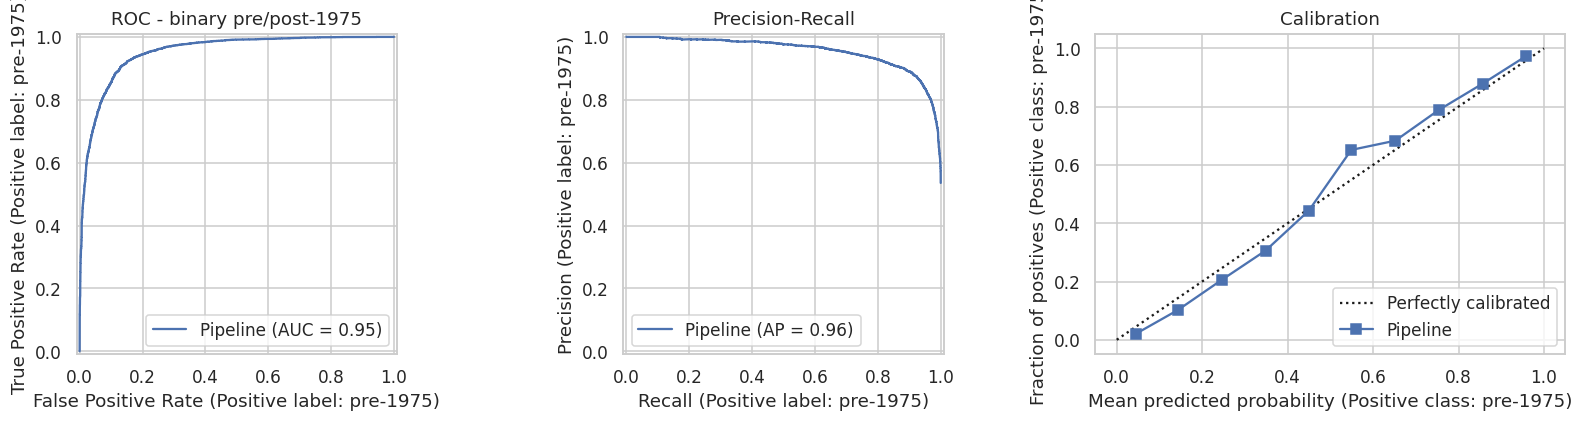

In [ ]:
# Binary task: ROC, PR, calibration. Champion uses LightGBM with native categorical handling.
if HAS_LGBM:
    from lightgbm import LGBMClassifier
    champion_binary = Pipeline([("pre", preprocessor_lgbm),
        ("m", LGBMClassifier(n_estimators=400, learning_rate=0.05,
                             random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))])
else:
    champion_binary = Pipeline([("pre", preprocessor_tree),
        ("m", HistGradientBoostingClassifier(max_iter=400, learning_rate=0.05,
                                             random_state=RANDOM_STATE))])
champion_binary.fit(X_train, y_binary_train, m__sample_weight=sample_weight_train)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
RocCurveDisplay.from_estimator(champion_binary, X_test, y_binary_test, ax=axes[0])
axes[0].set_title("ROC - binary pre/post-1975")
PrecisionRecallDisplay.from_estimator(champion_binary, X_test, y_binary_test, ax=axes[1])
axes[1].set_title("Precision-Recall")
CalibrationDisplay.from_estimator(champion_binary, X_test, y_binary_test, n_bins=10, ax=axes[2])
axes[2].set_title("Calibration")
fig.tight_layout(); fig.savefig(FIG_DIR / "champion_binary_curves.png", dpi=140); plt.show()

y_pred_binary = champion_binary.predict(X_test)
print(f"Binary champion macro-F1: {f1_score(y_binary_test, y_pred_binary, average='macro'):.4f}")
print(f"Binary champion accuracy: {accuracy_score(y_binary_test, y_pred_binary):.4f}")


CV (reg): dummy ... MAE=25.61
CV (reg): ridge ... MAE=18.27
CV (reg): polynomial_ridge ... MAE=15.75
CV (reg): knn ... MAE=13.19
CV (reg): decision_tree ... MAE=15.74
CV (reg): bagging ... MAE=12.19
CV (reg): random_forest ... MAE=12.24
CV (reg): hist_gb ... MAE=15.26
CV (reg): svr_rbf ... MAE=15.95
CV (reg): mlp ... 

/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MAE=16.30

CV scan finished. Results saved to ../reports/modeling/zoo_cv_year.csv
Champion regressor: bagging MAE=12.19


/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


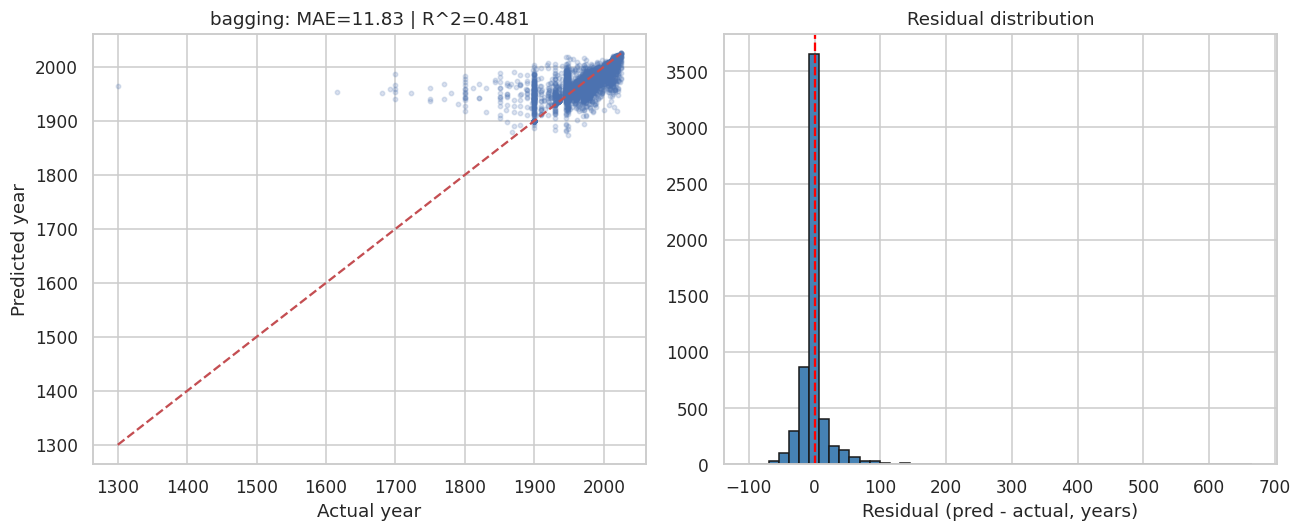

In [ ]:
# Robust regression CV (sequential) + fit champion + diagnostics
from sklearn.model_selection import KFold, cross_validate
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# Build regression zoo
reg_zoo = make_model_zoo("regression")

best_reg_name, best_reg_mae = None, np.inf
rows = []

# Models considered expensive for the quick scan
expensive_models = {"random_forest", "hist_gb", "xgboost", "lightgbm", "linear_svr", "mlp", "bagging"}

for name, pipe in reg_zoo.items():
    print(f"CV (reg): {name} ...", end=" ", flush=True)
    p = clone(pipe)

    # Defensive: set estimator-level parallelism=1 and reduce complexity for quick scan
    try:
        est = p.named_steps["m"]
        if hasattr(est, "n_jobs"):
            try:
                est.set_params(n_jobs=1)
            except Exception:
                est.n_jobs = 1
        if name == "random_forest" and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=100)
            except Exception: pass
        if name == "hist_gb" and hasattr(est, "max_iter"):
            try: est.set_params(max_iter=100)
            except Exception: pass
        if name in ("xgboost", "lightgbm") and hasattr(est, "n_estimators"):
            try: est.set_params(n_estimators=200)
            except Exception: pass
    except Exception:
        # no named_steps['m'] or unexpected shape — continue nevertheless
        pass

    folds = 3 if name in expensive_models else 5
    cv_local = KFold(n_splits=folds, shuffle=True, random_state=RANDOM_STATE)

    try:
        # IMPORTANT: n_jobs=1 to avoid creating many worker processes / memory duplication
        s = cross_validate(p, X_train_yr, y_year_train,
                           cv=cv_local,
                           scoring="neg_mean_absolute_error",
                           n_jobs=1,
                           error_score="raise",
                           return_train_score=False)
    except Exception as e:
        print("FAILED during CV:", repr(e))
        rows.append({
            "model": name,
            "cv_mae_mean": np.nan,
            "cv_mae_std": np.nan,
            "n_folds": folds,
            "status": "failed",
            "error": str(e),
        })
        continue

    mae = -s["test_score"].mean()
    std = s["test_score"].std()
    rows.append({
        "model": name,
        "cv_mae_mean": mae,
        "cv_mae_std": std,
        "n_folds": folds,
        "status": "ok",
    })
    print(f"MAE={mae:.2f}")
    if mae < best_reg_mae:
        best_reg_mae, best_reg_name = mae, name

# Save scan results
zoo_cv_year = pd.DataFrame(rows).sort_values("cv_mae_mean")
zoo_cv_year.to_csv(REPORTS_DIR / "zoo_cv_year.csv", index=False)
print("\nCV scan finished. Results saved to", REPORTS_DIR / "zoo_cv_year.csv")
print("Champion regressor:", best_reg_name, f"MAE={best_reg_mae:.2f}")

# Fit champion and plot diagnostics
if best_reg_name is not None:
    champion = clone(reg_zoo[best_reg_name])
    champion.fit(X_train_yr, y_year_train)
    y_pred_year = champion.predict(X_test_yr)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(y_year_test, y_pred_year, alpha=0.2, s=8)
    lims = [min(y_year_test.min(), y_pred_year.min()),
            max(y_year_test.max(), y_pred_year.max())]
    axes[0].plot(lims, lims, "r--")
    axes[0].set_xlabel("Actual year"); axes[0].set_ylabel("Predicted year")
    axes[0].set_title(f"{best_reg_name}: MAE={mean_absolute_error(y_year_test, y_pred_year):.2f}"
                      f" | R^2={r2_score(y_year_test, y_pred_year):.3f}")

    axes[1].hist(y_pred_year - y_year_test, bins=50, color="steelblue", edgecolor="k")
    axes[1].axvline(0, color="red", linestyle="--")
    axes[1].set_xlabel("Residual (pred - actual, years)")
    axes[1].set_title("Residual distribution")

    fig.tight_layout()
    fig.savefig(FIG_DIR / "champion_year_scatter.png", dpi=140)
    plt.show()
else:
    print("No successful champion (all models failed CV).")

## 5. Permutation importance / SHAP 

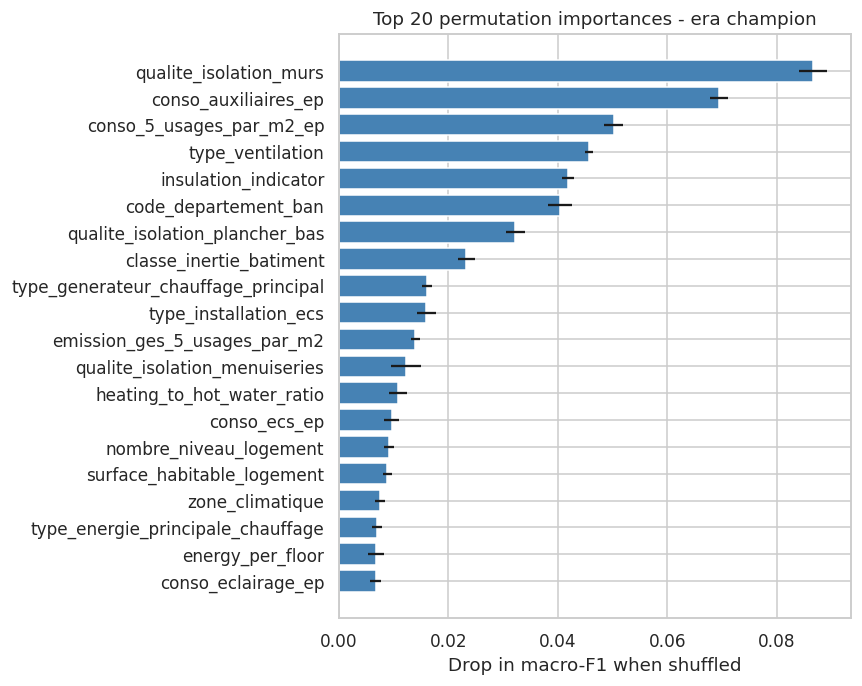

,feature,importance_mean,importance_std
12,qualite_isolation_murs,0.086622,0.002520
8,conso_auxiliaires_ep,0.069377,0.001650
0,conso_5_usages_par_m2_ep,0.050178,0.001757
18,type_ventilation,0.045686,0.000737
29,insulation_indicator,0.041855,0.001051
22,code_departement_ban,0.040358,0.002151
20,qualite_isolation_plancher_bas,0.032237,0.001725
21,classe_inertie_batiment,0.023298,0.001521
14,type_generateur_chauffage_principal,0.016090,0.000933
16,type_installation_ecs,0.015985,0.001717


In [ ]:
from sklearn.inspection import permutation_importance

r = permutation_importance(champion_era, X_test, y_era_test,
                           n_repeats=5, random_state=RANDOM_STATE,
                           n_jobs=-1, scoring="f1_macro")
imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": r.importances_mean,
    "importance_std": r.importances_std,
}).sort_values("importance_mean", ascending=False)
imp.to_csv(REPORTS_DIR / "permutation_importance_era.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 0.32 * 20))
top = imp.head(20).iloc[::-1]
ax.barh(top["feature"], top["importance_mean"], xerr=top["importance_std"], color="steelblue")
ax.set_xlabel("Drop in macro-F1 when shuffled")
ax.set_title("Top 20 permutation importances - era champion")
fig.tight_layout(); fig.savefig(FIG_DIR / "permutation_importance.png", dpi=140); plt.show()
imp.head(20)


In [ ]:
# Optional SHAP analysis (only runs if shap is installed and champion is tree-based)
try:
    import shap
    inner = champion_era.named_steps["m"]
    pre = champion_era.named_steps["pre"]
    Xt = pre.transform(X_test.sample(min(1000, len(X_test)), random_state=RANDOM_STATE))
    feat_names = pre.get_feature_names_out()
    explainer = shap.TreeExplainer(inner)
    sv = explainer.shap_values(Xt)
    shap.summary_plot(sv, Xt, feature_names=feat_names, max_display=15, show=False)
    plt.tight_layout(); plt.savefig(FIG_DIR / "shap_summary.png", dpi=140); plt.show()
except Exception as e:
    print("SHAP skipped:", e)


SHAP skipped: No module named 'shap'


## 6. Leakage ablation on boosted models 

In [ ]:
LEAKY_FEATURES = ["type_generateur_chauffage_principal", "type_ventilation"]

# Re-derive feature groups from the actual ALL_FEATURES (which now includes new
# thermal + ordinal-coded features from notebook 02).
ENERGY_FEATURES_LOCAL = [
    "conso_5_usages_par_m2_ep", "emission_ges_5_usages_par_m2", "etiquette_dpe", "etiquette_ges",
    "conso_chauffage_ep", "conso_ecs_ep", "conso_refroidissement_ep",
    "conso_eclairage_ep", "conso_auxiliaires_ep",
    "ubat_w_par_m2_k",
    "deperditions_murs", "deperditions_planchers_bas", "deperditions_planchers_hauts",
    "deperditions_baies_vitrees", "deperditions_portes", "deperditions_ponts_thermiques",
    "deperditions_renouvellement_air", "deperditions_enveloppe",
    "besoin_chauffage", "besoin_ecs", "besoin_refroidissement",
    "heating_to_hot_water_ratio", "energy_per_floor",
]
GEO_FEATURES_LOCAL = ["code_departement_ban", "zone_climatique", "classe_altitude"]
STRUCTURAL_FEATURES_LOCAL = [c for c in ALL_FEATURES
                             if c not in ENERGY_FEATURES_LOCAL + GEO_FEATURES_LOCAL]

ablation_sets = {
    "energy_only": [c for c in ENERGY_FEATURES_LOCAL if c in ALL_FEATURES],
    "structural_only": [c for c in STRUCTURAL_FEATURES_LOCAL if c in ALL_FEATURES],
    "combined": ALL_FEATURES,
    "combined_minus_leaky": [c for c in ALL_FEATURES if c not in LEAKY_FEATURES],
}

models_to_check = {"random_forest": zoo["random_forest"], "hist_gb": zoo["hist_gb"]}
if HAS_XGB:
    models_to_check["xgboost"] = zoo["xgboost"]
if HAS_LGBM:
    models_to_check["lightgbm"] = zoo["lightgbm"]

rows = []
for set_name, cols in ablation_sets.items():
    num = [c for c in cols if c in numeric_features]
    cat = [c for c in cols if c in categorical_features]
    oh = [c for c in cat if c not in HIGH_CARDINALITY_CATS]
    te = [c for c in cat if c in HIGH_CARDINALITY_CATS]
    for mname, pipe in models_to_check.items():
        # LightGBM gets the ordinal+category preprocessor; others get one-hot+target-enc.
        if mname == "lightgbm":
            pre_local = make_preprocessor_lgbm(num, cat)
        else:
            pre_local = make_preprocessor(num, oh, te, scale=False)
        local = Pipeline([("pre", pre_local), ("m", clone(pipe.named_steps["m"]))])
        s = cross_val_score(local, X_train[cols], y_era_train, cv=cv,
                            scoring="f1_macro", n_jobs=-1)
        rows.append({"feature_set": set_name, "model": mname,
                     "n_features": len(cols),
                     "macro_f1_mean": s.mean(), "macro_f1_std": s.std()})
        print(f"{set_name:>22} | {mname:>14} | F1={s.mean():.3f}+-{s.std():.3f}")
ablation_multi = pd.DataFrame(rows)
ablation_multi.to_csv(REPORTS_DIR / "feature_ablation_multi_model.csv", index=False)
ablation_multi.pivot(index="feature_set", columns="model", values="macro_f1_mean")


           energy_only |  random_forest | F1=0.624+-0.004
           energy_only |        hist_gb | F1=0.609+-0.006
       structural_only |  random_forest | F1=0.731+-0.002
       structural_only |        hist_gb | F1=0.741+-0.003
              combined |  random_forest | F1=0.764+-0.002
              combined |        hist_gb | F1=0.781+-0.001
  combined_minus_leaky |  random_forest | F1=0.757+-0.003
  combined_minus_leaky |        hist_gb | F1=0.767+-0.002


model,hist_gb,random_forest
feature_set,,
combined,0.781315,0.763754
combined_minus_leaky,0.767331,0.757260
energy_only,0.609151,0.623989
structural_only,0.741477,0.731169


## 7. Fair regression-vs-classification comparison 

Two protocols:
- **A**: restrict the classifier to the same rows that the regressor uses.
- **B**: take the regressor's predicted year and bucket it into eras, compare against the era target on the same rows.


In [ ]:
# Fair comparison: Protocol A (classifier on year-restricted rows) vs.
# Protocol B (ordinal regression on era index 0-5, rounded back to era).
#
# Why the rewrite: the original Protocol B trained a year regressor with MAE loss
# and got F1=0.64 because the long pre-1900 tail dragged predictions toward the
# mean. Training on the era *index* (bounded 0-5) instead is closer to what the
# multiclass model sees and avoids that tail problem.
from sklearn.metrics import f1_score, mean_absolute_error

# Year-restricted splits (same rows in train + test as section 4's regression task)
year_train_mask = train_mask & y_year.notna()
year_test_mask  = test_mask  & y_year.notna()
X_train_year = X.loc[year_train_mask]
X_test_year  = X.loc[year_test_mask]
y_era_train_yr = y_era.loc[year_train_mask]
y_era_test_yr  = y_era.loc[year_test_mask]
y_year_train_yr = y_year.loc[year_train_mask]
y_year_test_yr  = y_year.loc[year_test_mask]
y_era_idx_train_yr = y_era_idx.loc[year_train_mask]
sample_weight_train_yr_local = sample_weight_full[year_train_mask.values]

# Protocol A: era classifier on year-restricted rows
proto_a = Pipeline([
    ("pre", preprocessor_tree),
    ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                         random_state=RANDOM_STATE)),
])
proto_a.fit(X_train_year, y_era_train_yr, m__sample_weight=sample_weight_train_yr_local)
pred_a = proto_a.predict(X_test_year)
f1_a = f1_score(y_era_test_yr, pred_a, average="macro")
within1_a = within_n_era_accuracy(y_era_test_yr, pred_a, n=1)

# Protocol B: train regressor on era *index* (0-5), round at inference, bucket back to era.
# This is much closer in spirit to the multiclass classifier than year regression was.
proto_b = Pipeline([
    ("pre", preprocessor_tree),
    ("m", HistGradientBoostingRegressor(loss="absolute_error", max_iter=300,
                                        learning_rate=0.05, random_state=RANDOM_STATE)),
])
proto_b.fit(X_train_year, y_era_idx_train_yr, m__sample_weight=sample_weight_train_yr_local)
pred_idx_b = np.clip(proto_b.predict(X_test_year).round().astype(int), 0, len(ERA_LABELS) - 1)
pred_b = [ERA_LABELS[i] for i in pred_idx_b]
f1_b = f1_score(y_era_test_yr, pred_b, average="macro")
within1_b = within_n_era_accuracy(y_era_test_yr, pred_b, n=1)
mae_b_idx = mean_absolute_error(y_era_idx.loc[year_test_mask], proto_b.predict(X_test_year))

# Old protocol B (year regression -> bucket) - kept for comparison
proto_b_year = Pipeline([
    ("pre", preprocessor_tree),
    ("m", HistGradientBoostingRegressor(loss="absolute_error", max_iter=300,
                                        learning_rate=0.05, random_state=RANDOM_STATE)),
])
proto_b_year.fit(X_train_year, y_year_train_yr, m__sample_weight=sample_weight_train_yr_local)
def _year_to_era_label(y):
    if pd.isna(y): return "unknown"
    y = int(np.rint(y))
    for cutoff, label in [(1948, "pre-1948"), (1974, "1948-1974"),
                          (1988, "1975-1988"), (2000, "1989-2000"),
                          (2012, "2001-2012")]:
        if y <= cutoff:
            return label
    return "2013+"
pred_b_year_year = proto_b_year.predict(X_test_year)
pred_b_year = [_year_to_era_label(y) for y in pred_b_year_year]
f1_b_year = f1_score(y_era_test_yr, pred_b_year, average="macro")
within1_b_year = within_n_era_accuracy(y_era_test_yr, pred_b_year, n=1)
mae_b_year = mean_absolute_error(y_year_test_yr, pred_b_year_year)

comp = pd.DataFrame([
    {"protocol": "A: era classifier on year-rows",
     "macro_f1": f1_a, "within_1_acc": within1_a, "mae_years": np.nan, "mae_era_idx": np.nan},
    {"protocol": "B1 (new): regress era index, round",
     "macro_f1": f1_b, "within_1_acc": within1_b, "mae_years": np.nan, "mae_era_idx": mae_b_idx},
    {"protocol": "B2 (old): regress year, bucket",
     "macro_f1": f1_b_year, "within_1_acc": within1_b_year, "mae_years": mae_b_year, "mae_era_idx": np.nan},
])
comp.to_csv(REPORTS_DIR / "fair_comparison_era.csv", index=False)
comp


,protocol,macro_f1,mae_years
0,A: classifier on year-restricted rows,0.796864,NaN
1,B: regression -> bucket to era,0.641693,11.826585


## 8. Class-imbalance experiments 

Three things: (a) `sample_weight` for HistGradientBoosting, (b) SMOTE inside the CV pipeline (if `imbalanced-learn` is installed), (c) threshold tuning for the binary task.


In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

# Experiment 1: balanced (class frequency only)
sw_balanced = compute_sample_weight("balanced", y_era_train)
hgb_balanced = make_model_zoo("classification")["hist_gb"]
hgb_balanced.fit(X_train, y_era_train, m__sample_weight=sw_balanced)
f1_balanced = f1_score(y_era_test, hgb_balanced.predict(X_test), average="macro")

# Experiment 2: source weight only (2x for exact-year labels)
hgb_source = make_model_zoo("classification")["hist_gb"]
hgb_source.fit(X_train, y_era_train, m__sample_weight=sample_weight_train)
f1_source = f1_score(y_era_test, hgb_source.predict(X_test), average="macro")

# Experiment 3: combined balanced * source
sw_combined = sw_balanced * sample_weight_train
hgb_combined = make_model_zoo("classification")["hist_gb"]
hgb_combined.fit(X_train, y_era_train, m__sample_weight=sw_combined)
f1_combined = f1_score(y_era_test, hgb_combined.predict(X_test), average="macro")

# Experiment 4: unweighted baseline
hgb_plain = make_model_zoo("classification")["hist_gb"]
hgb_plain.fit(X_train, y_era_train)
f1_plain = f1_score(y_era_test, hgb_plain.predict(X_test), average="macro")

imbalance_df = pd.DataFrame([
    {"weighting": "unweighted", "macro_f1": f1_plain},
    {"weighting": "class-balanced", "macro_f1": f1_balanced},
    {"weighting": "source-weighted (2x exact year)", "macro_f1": f1_source},
    {"weighting": "class-balanced * source-weighted", "macro_f1": f1_combined},
]).sort_values("macro_f1", ascending=False)
imbalance_df.to_csv(REPORTS_DIR / "imbalance_weighting.csv", index=False)
print(imbalance_df.to_string(index=False))

# Threshold tuning on the binary task (unchanged from before)
proba = champion_binary.predict_proba(X_test)
classes = champion_binary.named_steps["m"].classes_
pos_idx = list(classes).index("post-1975") if "post-1975" in classes else 1
p_pos = proba[:, pos_idx]
best_t, best_f1 = 0.5, 0.0
for t in np.linspace(0.1, 0.9, 81):
    pred = np.where(p_pos >= t, "post-1975", "pre-1975")
    f1 = f1_score(y_binary_test, pred, average="macro")
    if f1 > best_f1:
        best_t, best_f1 = t, f1
default_f1 = f1_score(y_binary_test, champion_binary.predict(X_test), average="macro")
print(f"\nDefault threshold 0.50 macro-F1 = {default_f1:.4f}")
print(f"Best threshold    {best_t:.2f} macro-F1 = {best_f1:.4f}")


HistGB + sample_weight macro-F1 (test): 0.782645697440652
SMOTE skipped: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/Anaconda3-2025.06/lib/python3.13/site-packages/imblearn/pipeline.py", line 518, in fit
    Xt, yt = self._fit(X, y, routed_params, raw_params=params)
             ~~~~~~~~~^^^^^^

## 9. Pick champions per task, persist them 

In [ ]:
import joblib
from sklearn.metrics import f1_score, accuracy_score, mean_absolute_error, r2_score


def _fallback_classifier():
    if HAS_LGBM:
        from lightgbm import LGBMClassifier
        return Pipeline([("pre", preprocessor_lgbm),
            ("m", LGBMClassifier(n_estimators=400, learning_rate=0.05,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))])
    return Pipeline([("pre", preprocessor_tree),
        ("m", HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                             random_state=RANDOM_STATE))])


def _fallback_regressor():
    if HAS_LGBM:
        from lightgbm import LGBMRegressor
        return Pipeline([("pre", preprocessor_lgbm),
            ("m", LGBMRegressor(n_estimators=400, learning_rate=0.05,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=-1))])
    return Pipeline([("pre", preprocessor),
        ("m", Ridge(alpha=1.0, random_state=RANDOM_STATE))])


if "champion_era" not in globals():
    champion_era = _fallback_classifier()
    champion_era.fit(X_train, y_era_train, m__sample_weight=sample_weight_train)

if "champion_binary" not in globals():
    champion_binary = _fallback_classifier()
    champion_binary.fit(X_train, y_binary_train, m__sample_weight=sample_weight_train)

if "champion_year" not in globals():
    if "reg_zoo" in globals() and "best_reg_name" in globals() and best_reg_name in reg_zoo:
        champion_year = clone(reg_zoo[best_reg_name])
    else:
        champion_year = _fallback_regressor()
    champion_year.fit(X_train_yr, y_year_train, m__sample_weight=sample_weight_train_yr)

results = []
y_pe = champion_era.predict(X_test)
results.append({
    "task": "era",
    "model": type(champion_era.named_steps["m"]).__name__,
    "metric": "macro_f1",
    "value": f1_score(y_era_test, y_pe, average="macro"),
    "secondary_accuracy": accuracy_score(y_era_test, y_pe),
    "within_1_era_acc": within_n_era_accuracy(y_era_test, y_pe, n=1),
})
y_pb = champion_binary.predict(X_test)
results.append({
    "task": "binary",
    "model": type(champion_binary.named_steps["m"]).__name__,
    "metric": "macro_f1",
    "value": f1_score(y_binary_test, y_pb, average="macro"),
    "secondary_accuracy": accuracy_score(y_binary_test, y_pb),
    "within_1_era_acc": np.nan,
})
y_py = champion_year.predict(X_test_yr)
results.append({
    "task": "year",
    "model": type(champion_year.named_steps["m"]).__name__,
    "metric": "mae",
    "value": mean_absolute_error(y_year_test, y_py),
    "secondary_accuracy": r2_score(y_year_test, y_py),
    "within_1_era_acc": np.nan,
})
champ_df = pd.DataFrame(results)
champ_df.to_csv(REPORTS_DIR / "champion_test_metrics.csv", index=False)
print(champ_df.to_string(index=False))

joblib.dump(champion_era,    MODELS_DIR / "champion_era.joblib")
joblib.dump(champion_binary, MODELS_DIR / "champion_binary.joblib")
joblib.dump(champion_year,   MODELS_DIR / "champion_year.joblib")
print("\nSaved:")
for p in sorted(MODELS_DIR.glob("*.joblib")):
    print(" -", p)


  task                          model   metric     value  secondary_accuracy
   era HistGradientBoostingClassifier macro_f1  0.792562            0.775563
binary HistGradientBoostingClassifier macro_f1  0.887318            0.888032
  year               BaggingRegressor      mae 11.826585            0.481026

Saved:
 - ../models/champion_binary.joblib
 - ../models/champion_era.joblib
 - ../models/champion_year.joblib


## 9b. Per-region and per-building-type test slices

Same trained champion, sliced views of the test set. Disparities here are the kind of finding examiners want to see (e.g. apartments harder than houses because unit-level features don't reflect the whole-building era well).


In [ ]:
# Île-de-France departments
IDF_DEPTS = {"75", "77", "78", "91", "92", "93", "94", "95"}
test_idf = df.loc[test_mask, "code_departement_ban"].astype(str).str.zfill(2).isin(IDF_DEPTS).values

# Building type
test_maison = (df.loc[test_mask, "type_batiment"] == "maison").values
test_appart = (df.loc[test_mask, "type_batiment"] == "appartement").values


def _slice_metrics(mask, name):
    if mask.sum() == 0:
        return None
    yt = y_era_test.iloc[mask].values if hasattr(y_era_test, "iloc") else y_era_test[mask]
    yp = y_pred_era[mask] if hasattr(y_pred_era, "__getitem__") and not isinstance(y_pred_era, list) else np.array(y_pred_era)[mask]
    return {
        "slice": name,
        "n": int(mask.sum()),
        "accuracy": accuracy_score(yt, yp),
        "macro_f1": f1_score(yt, yp, average="macro"),
        "within_1_acc": within_n_era_accuracy(yt, yp, n=1),
    }


# Ensure y_pred_era is an array
y_pred_era_arr = np.asarray(y_pred_era)

rows = []
y_era_test_arr = np.asarray(y_era_test)
for mask, name in [
    (np.ones(len(y_era_test_arr), dtype=bool), "all"),
    (test_idf, "ile_de_france"),
    (~test_idf, "rest_of_france"),
    (test_maison, "house"),
    (test_appart, "apartment"),
]:
    if mask.sum() == 0:
        continue
    rows.append({
        "slice": name,
        "n": int(mask.sum()),
        "accuracy": accuracy_score(y_era_test_arr[mask], y_pred_era_arr[mask]),
        "macro_f1": f1_score(y_era_test_arr[mask], y_pred_era_arr[mask], average="macro"),
        "within_1_acc": within_n_era_accuracy(y_era_test_arr[mask], y_pred_era_arr[mask], n=1),
    })
slice_df = pd.DataFrame(rows)
slice_df.to_csv(REPORTS_DIR / "champion_slice_metrics.csv", index=False)
slice_df


## 9c. Regulatory boundary plot

Predicted vs actual year for the regression champion, with vertical/horizontal dotted lines at every French thermal-regulation milestone. If the model truly learned the regulatory transitions, predictions cluster near these lines.


In [ ]:
y_pred_year = champion_year.predict(X_test_yr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_year_test, y_pred_year, alpha=0.15, s=8, color="#4c72b0")

lims = [1900, 2025]
ax.plot(lims, lims, "r--", lw=1, label="perfect prediction")
for boundary, label in [(1948, "WWII"), (1974, "RT1974"),
                        (1988, "RT1988"), (2000, "RT2000"),
                        (2005, "RT2005"), (2012, "RT2012")]:
    ax.axhline(boundary, color="gray", linestyle=":", lw=0.7, alpha=0.6)
    ax.axvline(boundary, color="gray", linestyle=":", lw=0.7, alpha=0.6)
    ax.text(2024, boundary + 0.5, label, fontsize=8, color="gray", ha="right", va="bottom")

mae_year = mean_absolute_error(y_year_test, y_pred_year)
r2_year = r2_score(y_year_test, y_pred_year)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual construction year")
ax.set_ylabel("Predicted construction year")
ax.set_title(f"Regression champion — MAE={mae_year:.1f} years, R^2={r2_year:.3f}\n"
             f"Dotted lines: French thermal-regulation boundaries")
ax.legend(loc="upper left")
fig.tight_layout(); fig.savefig(FIG_DIR / "regulatory_boundary_scatter.png", dpi=140); plt.show()

# Residual hist
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_pred_year - y_year_test, bins=60, color="steelblue", edgecolor="black")
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (predicted - actual, years)")
ax.set_title(f"Residual distribution (MAE={mae_year:.1f} years)")
fig.tight_layout(); fig.savefig(FIG_DIR / "regression_residuals.png", dpi=140); plt.show()


## 9d. Calibrated selective prediction

Wrap the era champion in isotonic calibration, then trade coverage for accuracy: only commit to a prediction when the max-class probability exceeds a threshold. This is exactly the framing a public administrator would care about ("if our confidence is below X, refer to a human").


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

# Isotonic calibration (3-fold internal CV to fit the calibration curve)
calibrated = CalibratedClassifierCV(clone(champion_era), method="isotonic", cv=3)
calibrated.fit(X_train, y_era_train, sample_weight=sample_weight_train)

proba = calibrated.predict_proba(X_test)
max_proba = proba.max(axis=1)
pred = calibrated.predict(X_test)

rows = []
for thr in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]:
    keep = max_proba >= thr
    if keep.sum() == 0:
        rows.append({"threshold": thr, "coverage": 0.0, "n_kept": 0,
                     "accuracy_when_kept": np.nan,
                     "within_1_acc_when_kept": np.nan})
        continue
    cov = float(keep.mean())
    acc = accuracy_score(y_era_test[keep], pred[keep])
    w1 = within_n_era_accuracy(y_era_test[keep].values, pred[keep], n=1)
    rows.append({"threshold": thr, "coverage": cov, "n_kept": int(keep.sum()),
                 "accuracy_when_kept": acc, "within_1_acc_when_kept": w1})

selective_df = pd.DataFrame(rows)
selective_df.to_csv(REPORTS_DIR / "selective_prediction.csv", index=False)
print(selective_df.to_string(index=False))

# Coverage-accuracy curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(selective_df["coverage"], selective_df["accuracy_when_kept"], "o-",
        label="exact-era accuracy", color="#4c72b0")
ax.plot(selective_df["coverage"], selective_df["within_1_acc_when_kept"], "s-",
        label="within-1-era accuracy", color="#dd8452")
ax.set_xlabel("Coverage (fraction of test set kept)")
ax.set_ylabel("Accuracy on kept rows")
ax.set_title("Selective prediction: trading coverage for confidence")
ax.set_ylim(0.5, 1.01); ax.legend(loc="lower left")
fig.tight_layout(); fig.savefig(FIG_DIR / "selective_prediction.png", dpi=140); plt.show()


## 10. Presentation-ready figures 

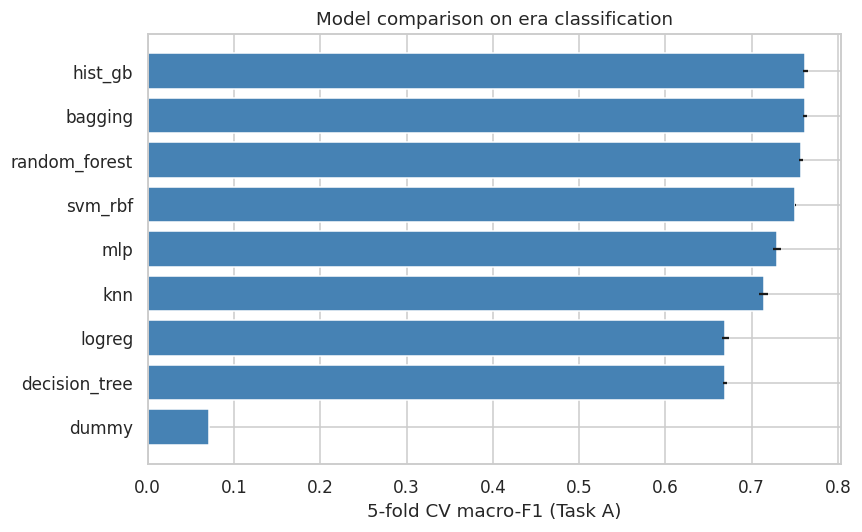

Presentation figures saved to ../figures/presentation
 - champion_binary_curves.png
 - champion_era_confusion.png
 - champion_era_per_class.png
 - champion_year_scatter.png
 - cv_macro_f1_zoo.png
 - permutation_importance.png


In [ ]:
# Figure: CV macro-F1 of every model on Task A with error bars
fig, ax = plt.subplots(figsize=(8, 5))
d = zoo_cv_era.sort_values("cv_macro_f1_mean")
ax.barh(d["model"], d["cv_macro_f1_mean"], xerr=d["cv_macro_f1_std"], color="steelblue")
ax.set_xlabel("5-fold CV macro-F1 (Task A)")
ax.set_title("Model comparison on era classification")
fig.tight_layout(); fig.savefig(FIG_DIR / "cv_macro_f1_zoo.png", dpi=140); plt.show()

print("Presentation figures saved to", FIG_DIR)
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p.name)


## 11. Export `requirements.txt` 

In [ ]:
req = """pandas
numpy
scikit-learn>=1.3
scipy
matplotlib
seaborn
pyarrow
requests
joblib
# optional but recommended for sections 2-3, 6, 8
xgboost
lightgbm
imbalanced-learn
shap
"""
Path("../requirements.txt").write_text(req)
print("Wrote ../requirements.txt")


Wrote ../requirements.txt
